In [1]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import numpy as np
from pathlib import Path
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, precision_recall_curve
import seaborn as sns
import matplotlib.pyplot as plt
from helper import DeepfakeDataset, face_detect_trace, fft_transform
from models import Model1, Model0, Model2, Model3

SEED = 38

torch.manual_seed(SEED)

In [2]:
print("Test Dataset")
test_dataset = DeepfakeDataset("preprocessed/test", mode="test")
sample = test_dataset[0]
print(sample["spatial"].shape)
print(sample["frequency"].shape)
print(sample["label"])

Test Dataset
torch.Size([16, 3, 224, 224])
torch.Size([16, 1, 224, 224])
tensor(1.)


In [3]:
test_loader   = DataLoader(test_dataset, batch_size=4, shuffle=False)

model = Model3()

model.load_state_dict(torch.load("Model3.pth"))

<All keys matched successfully>

In [4]:
def test(model, loader = test_loader):
    model.eval()

    all_preds = []
    all_labels = []
    all_probs = [] 
    
    pbar = tqdm(loader)

    with torch.no_grad():
        for batch in pbar:
            spatial = batch["spatial"]
            frequency = batch["frequency"]
            labels = batch["label"].unsqueeze(1)

            out, frame_preds, weight = model(spatial, frequency)

            probs = torch.sigmoid(out)

            all_probs.extend(probs.cpu().numpy())
            preds = (probs > 0.5).float()

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    return np.array(all_preds), np.array(all_labels), np.array(all_probs)

preds, labels, probs = test(model)

acc = accuracy_score(labels, preds)
prec = precision_score(labels, preds)
rec = recall_score(labels, preds)
f1 = f1_score(labels, preds)

print("\nModel metrics")
print(f"Accuracy: {acc}")
print(f"Precision: {prec}")
print(f"Recall: {rec}")
print(f"F1: {f1}")

100%|██████████| 120/120 [03:09<00:00,  1.58s/it]


Model metrics
Accuracy: 0.9083333333333333
Precision: 0.9054054054054054
Recall: 0.8973214285714286
F1: 0.9013452914798207


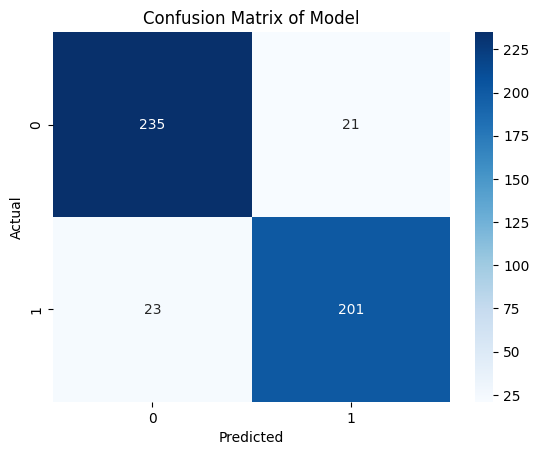

In [5]:
cm = confusion_matrix(labels, preds)

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix of Model")
plt.show()